Planar data classification with one hidden layer

we will learn :

. implement a 2-class classification nerual network with a single hidden layer
. Use units with a non-linear actication function, such as tanh
. Compute the cross entropy loss
. Implement forward and backward propagation

In [1]:
# Run this first to load Week 3 helper files
import urllib.request

files = {
    "testCases.py": "https://raw.githubusercontent.com/AlbertHG/Coursera-Deep-Learning-deeplearning.ai/master/01-Neural%20Networks%20and%20Deep%20Learning/week3/testCases.py",
    "planar_utils.py": "https://raw.githubusercontent.com/rvarun7777/Deep_Learning/master/Neural%20Networks%20and%20Deep%20Learning/Week%203/Planar%20data%20classification%20with%20one%20hidden%20layer/planar_utils.py",
}

for path, url in files.items():
    try:
        urllib.request.urlretrieve(url, path)
        print(f"✓ Downloaded {path}")
    except Exception as e:
        print(f"✗ Failed {path}: {e}")

print("Done.")

✓ Downloaded testCases.py
✓ Downloaded planar_utils.py
Done.


In [2]:
# import sys
# !"{sys.executable}" -m pip install scikit-learn

In [3]:
# package impotrs
# Package imports
import numpy as np
import matplotlib.pyplot as plt
from testCases import *
import sklearn
import sklearn.datasets
import sklearn.linear_model
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

%matplotlib inline

np.random.seed(1)

In [4]:
X, Y = load_planar_dataset()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2, 400)
Y shape: (1, 400)


Why not (400, 2) instead? Both shapes could store the same data, so why does Andrew Ng choose (2, 400)?
It's a convention in deep learning — each row is a feature, each column is one example. So when you do matrix math later, things like W · X just work out cleanly without needing to transpose everything.

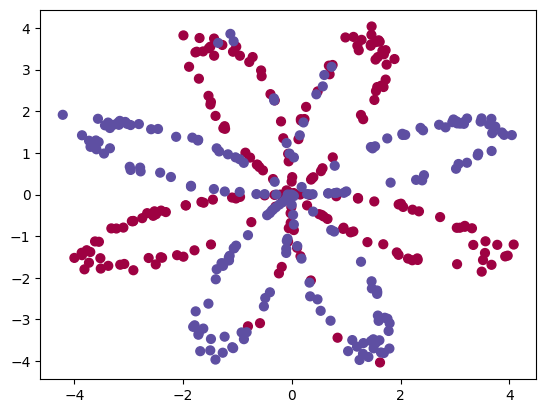

In [5]:
plt.scatter(X[0, :], X[1, :], c=Y[0, :], s=40, cmap=plt.cm.Spectral)
plt.show()

C:\Users\mofqt\OneDrive\Desktop\deep learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\mofqt\OneDrive\Desktop\deep learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


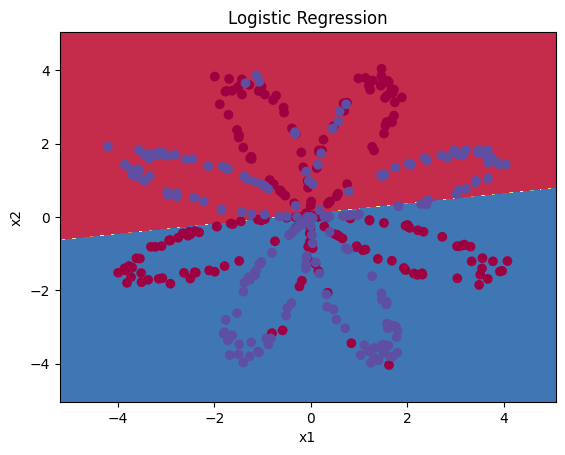

Accuracy: 47.0 %


In [6]:
# lets test LR here !
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, Y[0, :])

plot_decision_boundary(lambda x: clf.predict(x), X, Y[0, :])
plt.title("Logistic Regression")
plt.show()

print("Accuracy:", np.mean(clf.predict(X.T) == Y[0, :]) * 100, "%")

How does adding a hidden layer fix this ? 

LR is this : input -> weighted sum -> sigmoid -> output

A neural network with 1 hidden layer is : 

input -> hidden layer (multiple neurons) -> sigmoid -> output

In [7]:
def layer_sizes(X, Y):
    n_x = X.shape[0]  # number of input features
    n_h = 4           # hidden neurons (we choose this)
    n_y = Y.shape[0]  # number of outputs
    return (n_x, n_h, n_y)

# testing
n_x, n_h, n_y = layer_sizes(X, Y)
print("n_x:", n_x)
print("n_h:", n_h)
print("n_y:", n_y)

n_x: 2
n_h: 4
n_y: 1


In [8]:
def initialize_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

# testing
parameters = initialize_parameters(n_x, n_h, n_y)
print("W1 shape:", parameters["W1"].shape)
print("b1 shape:", parameters["b1"].shape)
print("W2 shape:", parameters["W2"].shape)
print("b2 shape:", parameters["b2"].shape)

W1 shape: (4, 2)
b1 shape: (4, 1)
W2 shape: (1, 4)
b2 shape: (1, 1)


as you can see each W explains the input/output from it and to the next layer :
W1 is (n_h,n_x) = (4,2) it connects 2 inputs to 4 hidden neurons
W2 is (n_y,n_h) = (1,4) it connects 4 hidden neurons to 1 output
The rule is always (next layer, current layer)

In [9]:
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    # During backprop you need those intermediate values to compute the gradients. 
    # Without the cache you'd have to recalculate everything all over again.
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    
    return A2, cache 

# test
A2, cache = forward_propagation(X, parameters)
print("A2 shape:", A2.shape)
print("A2 sample:", A2[:, :5])  # first 5 predictions

A2 shape: (1, 400)
A2 sample: [[0.49979195 0.5000657  0.50005805 0.50008746 0.49984061]]


In [10]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    
    logprobs = np.multiply(Y, np.log(A2)) + np.multiply(1 - Y, np.log(1 - A2))
    cost = -1/m * np.sum(logprobs)
    
    return cost

# test
cost = compute_cost(A2, Y)
print("Cost:", cost)

Cost: 0.6931125167719424


fact : When your model predicts exactly 0.5 for everything (pure random guessing), the math of cross-entropy( cost function ) always gives you ln(2). It's the cost of knowing absolutely nothing.
Think of it as the "I have no idea" baseline. As training progresses, this number should drop significantly toward 0.

In [11]:
def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

# test
grads = backward_propagation(parameters, cache, X, Y)
print("dW1 shape:", grads["dW1"].shape)
print("dW2 shape:", grads["dW2"].shape)

dW1 shape: (4, 2)
dW2 shape: (1, 4)


In [12]:
def update_parameters(parameters, grads, learning_rate=.1):
    W1 = parameters["W1"] - learning_rate * grads["dW1"]
    b1 = parameters["b1"] - learning_rate * grads["db1"]
    W2 = parameters["W2"] - learning_rate * grads["dW2"]
    b2 = parameters["b2"] - learning_rate * grads["db2"]
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

# test it
parameters = update_parameters(parameters, grads)
print("W1:", parameters["W1"])

W1: [[ 0.00819991  0.00731131]
 [-0.01421959 -0.00522157]
 [-0.00107923 -0.0010349 ]
 [-0.0078497   0.02100615]]


*****************************************************
THE MAIN LOOP **** IMPORTANT ****
for each iteration:
    1. forward prop  → get predictions
    2. compute cost  → measure how wrong
    3. backward prop → compute gradients
    4. update params → nudge weights

In [13]:
def nn_model(X, Y, n_h, num_iterations=10000, print_cost=False) :
    n_x, _, n_y = layer_sizes(X, Y)

    parameters = initialize_parameters(n_x, n_h, n_y)

    for i in range(num_iterations) :
        
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)
        
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i:<4}: {cost}")
    
    return parameters

In [14]:
parameters = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

Cost after iteration 0   : 0.6931434753144265
Cost after iteration 1000: 0.28130840121749257
Cost after iteration 2000: 0.26897412073655963
Cost after iteration 3000: 0.261989765906824
Cost after iteration 4000: 0.2574261863996119
Cost after iteration 5000: 0.25427361838230034
Cost after iteration 6000: 0.2519929783142008
Cost after iteration 7000: 0.2502791627177332
Cost after iteration 8000: 0.24895062786039254
Cost after iteration 9000: 0.24789380489307575


you will see a pattern here its called :
diminishing returns and it's completely normal in gradient descent.
At the start the weights are way off, so there's a lot of "low hanging fruit" to fix — big gradients, big steps, big improvement. But as the network gets closer to the minimum, the terrain flattens out and steps get smaller and smaller.
Think of it like pushing a car that's stuck — the hardest push is the first one to get it rolling, after that it gets easier but the gains per push get smaller.

In [15]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    predictions = A2 > 0.5
    return predictions

In [16]:
predictions = predict(parameters, X)
print("Accuracy:", np.mean(predictions == Y) * 100, "%")

Accuracy: 91.25 %


In [17]:
for n_h in [1, 2, 4, 8, 16, 32]:
    parameters = nn_model(X, Y, n_h=n_h, num_iterations=5000)
    predictions = predict(parameters, X)
    accuracy = np.mean(predictions == Y) * 100
    print(f"n_h = {n_h} → Accuracy: {accuracy}%")

n_h = 1 → Accuracy: 67.5%
n_h = 2 → Accuracy: 67.25%
n_h = 4 → Accuracy: 90.75%
n_h = 8 → Accuracy: 89.75%
n_h = 16 → Accuracy: 91.0%
n_h = 32 → Accuracy: 90.5%


In [22]:
# hidden_layer_sizes = [1, 4, 16, 32]
# iteration_counts = [100, 1000, 5000, 10000]

# for n_h in hidden_layer_sizes:
#     for iterations in iteration_counts:
#         parameters = nn_model(X, Y, n_h=n_h, num_iterations=iterations)
#         predictions = predict(parameters, X)
#         accuracy = np.mean(predictions == Y) * 100
        
#         plot_decision_boundary(lambda x, p=parameters: predict(p, x.T), X, Y[0, :])
#         plt.title(f"n_h={n_h} | iter={iterations} | Acc: {accuracy:.1f}%")
#         plt.show()
#         plt.close()

In [23]:
noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure = load_extra_datasets()

datasets = {
    "noisy_circles": noisy_circles,
    "noisy_moons": noisy_moons,
    "gaussian_quantiles": gaussian_quantiles,
}

# for name, data in datasets.items():
#     X_d, Y_d = data
#     plt.scatter(X_d[:, 0], X_d[:, 1], c=Y_d, cmap=plt.cm.Spectral)
#     plt.title(name)
#     plt.show()
#     plt.close()

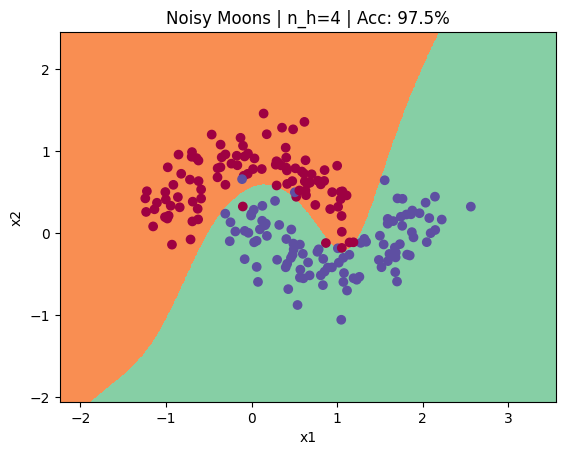

In [24]:
X_d, Y_d = noisy_moons
X_d = X_d.T
Y_d = Y_d.reshape(1, -1)

parameters = nn_model(X_d, Y_d, n_h=4, num_iterations=10000)
predictions = predict(parameters, X_d)
accuracy = np.mean(predictions == Y_d) * 100

plot_decision_boundary(lambda x, p=parameters: predict(p, x.T), X_d, Y_d[0, :])
plt.title(f"Noisy Moons | n_h=4 | Acc: {accuracy:.1f}%")
plt.show()
plt.close()

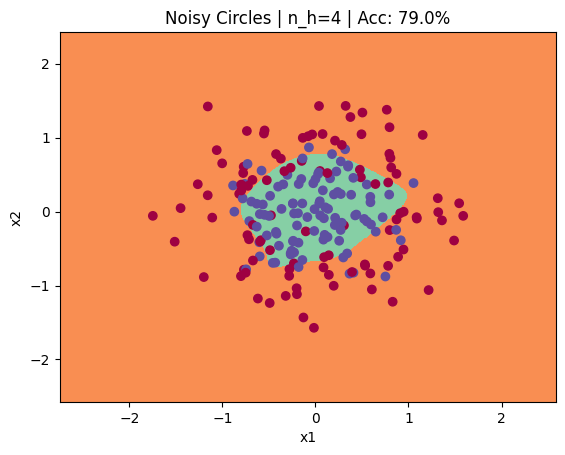

In [25]:
X_d, Y_d = noisy_circles
X_d = X_d.T
Y_d = Y_d.reshape(1, -1)

parameters = nn_model(X_d, Y_d, n_h=4, num_iterations=10000)
predictions = predict(parameters, X_d)
accuracy = np.mean(predictions == Y_d) * 100

plot_decision_boundary(lambda x, p=parameters: predict(p, x.T), X_d, Y_d[0, :])
plt.title(f"Noisy Circles | n_h=4 | Acc: {accuracy:.1f}%")
plt.show()
plt.close()

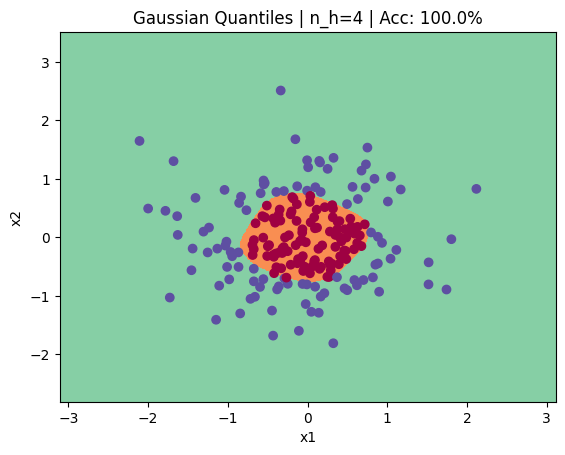

In [26]:
X_d, Y_d = gaussian_quantiles
X_d = X_d.T
Y_d = Y_d.reshape(1, -1)

parameters = nn_model(X_d, Y_d, n_h=4, num_iterations=10000)
predictions = predict(parameters, X_d)
accuracy = np.mean(predictions == Y_d) * 100

plot_decision_boundary(lambda x, p=parameters: predict(p, x.T), X_d, Y_d[0, :])
plt.title(f"Gaussian Quantiles | n_h=4 | Acc: {accuracy:.1f}%")
plt.show()
plt.close()

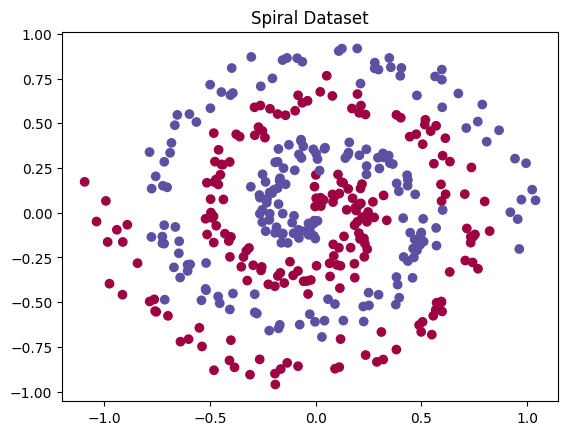

In [28]:
def load_spiral_dataset():
    np.random.seed(1)
    m = 400
    N = m // 2
    
    X = np.zeros((m, 2))
    Y = np.zeros(m, dtype='uint8')
    
    for j in range(2):
        ix = range(N * j, N * (j + 1))
        t = np.linspace(j * np.pi, (j + 3.5) * np.pi, N) + np.random.randn(N) * 0.15
        r = np.linspace(0.1, 1, N) + np.random.randn(N) * 0.05
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        Y[ix] = j
    
    X = X.T
    Y = Y.reshape(1, -1)
    return X, Y

X_d, Y_d = load_spiral_dataset()
plt.scatter(X_d[0, :], X_d[1, :], c=Y_d[0, :], cmap=plt.cm.Spectral)
plt.title("Spiral Dataset")
plt.show()
plt.close()

Cost after iteration 0   : 0.6931627651207865
Cost after iteration 1000: 0.6689913954157819
Cost after iteration 2000: 0.6689137617606127
Cost after iteration 3000: 0.6688786894136755
Cost after iteration 4000: 0.6688572618512791
Cost after iteration 5000: 0.6688408342496027
Cost after iteration 6000: 0.6688248838214227
Cost after iteration 7000: 0.6688030686755395
Cost after iteration 8000: 0.66875209300098
Cost after iteration 9000: 0.6684274048286597
Cost after iteration 10000: 0.6646319496354309
Cost after iteration 11000: 0.6501129586046152
Cost after iteration 12000: 0.6303815675201944
Cost after iteration 13000: 0.5841058296416466
Cost after iteration 14000: 0.5034149917301766
Cost after iteration 15000: 0.4399459063077069
Cost after iteration 16000: 0.41346770879454037
Cost after iteration 17000: 0.40503152800000564
Cost after iteration 18000: 0.4007430690845925
Cost after iteration 19000: 0.39801090346546647
Cost after iteration 20000: 0.39608565635096
Cost after iteration 210

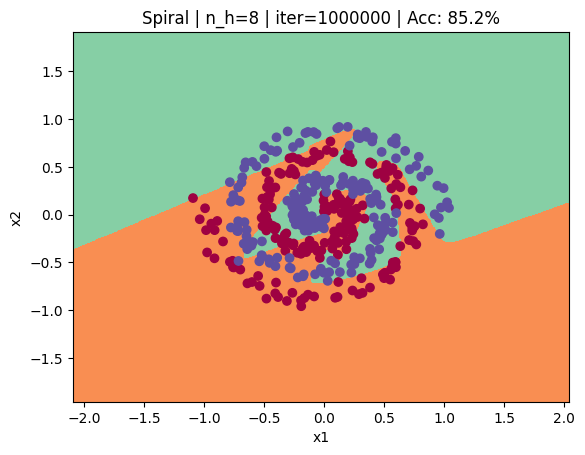

In [35]:
parameters = nn_model(X_d, Y_d, n_h=8, num_iterations=300000, print_cost=True)
predictions = predict(parameters, X_d)
accuracy = np.mean(predictions == Y_d) * 100

plot_decision_boundary(lambda x, p=parameters: predict(p, x.T), X_d, Y_d[0, :])
plt.title(f"Spiral | n_h=8 | iter=1000000 | Acc: {accuracy:.1f}%")
plt.show()
plt.close()